# Runtime Comparison Plots (qubit-TransmonCross-Hamiltonian_params)

This notebook reads saved timing CSVs from `results/runtime` and writes figures to `plots`. It does not load Keras models, run Ansys, or regenerate samples.

## Paths

In [1]:
import os
from pathlib import Path


EXPERIMENT_NAME = "model_predict_qubit_TransmonCross_Hamiltonian_params"
CANDIDATES = [
    Path.cwd(),
    Path.cwd() / "experiments" / EXPERIMENT_NAME,
    Path.cwd().parent / EXPERIMENT_NAME,
]
EXPERIMENT_DIR = next(
    (path.resolve() for path in CANDIDATES if (path / "results" / "runtime").exists()),
    None,
)
if EXPERIMENT_DIR is None:
    raise FileNotFoundError(
        "Could not locate the Hamiltonian experiment directory. Run this notebook "
        "from the repo root or from the experiment folder."
    )

RUNTIME_DIR = EXPERIMENT_DIR / "results" / "runtime"
PLOTS_DIR = EXPERIMENT_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
MPLCONFIGDIR = EXPERIMENT_DIR / "results" / "cache" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))
os.environ.setdefault("XDG_CACHE_HOME", str(EXPERIMENT_DIR / "results" / "cache"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ML_SUMMARY_PATH = RUNTIME_DIR / "ml_30_runtime_batch_benchmark_summary.csv"
ANSYS_TIMES_PATH = RUNTIME_DIR / "Ansys_simulation_times_100samples.csv"

print(f"Runtime data dir: {RUNTIME_DIR}")
print(f"Plots dir:        {PLOTS_DIR}")

Runtime data dir: /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime
Plots dir:        /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots


## Load Saved Timings

In [2]:
ml_df = pd.read_csv(ML_SUMMARY_PATH)
ansys_df = pd.read_csv(ANSYS_TIMES_PATH)

required_ml_columns = {
    "benchmark",
    "device",
    "batch_number",
    "mean_time_per_sample_seconds",
    "std_time_per_sample_seconds",
    "mean_time_per_sample_ms",
}
missing_ml_columns = sorted(required_ml_columns.difference(ml_df.columns))
if missing_ml_columns:
    raise ValueError(f"Missing columns in {ML_SUMMARY_PATH.name}: {missing_ml_columns}")

required_ansys_columns = {"Full_Time", "Ansys_Solver_Only"}
missing_ansys_columns = sorted(required_ansys_columns.difference(ansys_df.columns))
if missing_ansys_columns:
    raise ValueError(f"Missing columns in {ANSYS_TIMES_PATH.name}: {missing_ansys_columns}")

ml_df["device"] = ml_df["device"].str.upper()
ml_df = ml_df.sort_values(["benchmark", "device", "batch_number"]).reset_index(drop=True)

print(f"Loaded {len(ml_df)} ML timing rows from {ML_SUMMARY_PATH.name}")
print(f"Loaded {len(ansys_df)} Ansys timing rows from {ANSYS_TIMES_PATH.name}")

Loaded 48 ML timing rows from ml_30_runtime_batch_benchmark_summary.csv
Loaded 100 Ansys timing rows from Ansys_simulation_times_100samples.csv


## Comparison Table

In [3]:
BENCHMARK_LABELS = {
    "inverse+surrogate": "Inverse + surrogate",
    "surrogate-only": "Surrogate only",
}
BENCHMARK_ORDER = ["inverse+surrogate", "surrogate-only"]
DEVICE_ORDER = ["CPU", "GPU"]
ORANGE = "#E87A00"
ORANGE_LIGHT = "#FFF4E6"
PURPLE = "#7B68AE"
PURPLE_LIGHT = "#E8E4F0"
GREEN = "#3D8B3D"
GREEN_LIGHT = "#E8F5E8"
BLUE = "#3F6F8B"
BLUE_LIGHT = "#B0CCDE"
TEXT_DIM = "#555555"
GREY_LIGHT = "#F5F5F5"

METHOD_FACE_COLORS = {
    "Ansys": GREY_LIGHT,
    "Inverse + surrogate (CPU)": BLUE_LIGHT,
    "Inverse + surrogate (GPU)": GREEN_LIGHT,
    "Surrogate only (CPU)": ORANGE_LIGHT,
    "Surrogate only (GPU)": PURPLE_LIGHT,
}
METHOD_EDGE_COLORS = {
    "Ansys": TEXT_DIM,
    "Inverse + surrogate (CPU)": BLUE,
    "Inverse + surrogate (GPU)": GREEN,
    "Surrogate only (CPU)": ORANGE,
    "Surrogate only (GPU)": PURPLE,
}


def method_label(benchmark, device):
    return f"{BENCHMARK_LABELS.get(benchmark, benchmark)} ({device})"


def save_figure(fig, stem):
    pdf_path = PLOTS_DIR / f"{stem}.pdf"
    png_path = PLOTS_DIR / f"{stem}.png"
    fig.savefig(pdf_path, bbox_inches="tight")
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    print(f"Saved plot -> {pdf_path}")
    print(f"Saved plot -> {png_path}")


def format_speedup(value):
    if value < 1000:
        return f"{value:,.1f}x"
    if value < 100000:
        return f"{value:,.0f}x"
    return f"{value:.1e}x"


def build_comparison_table(ml_df, ansys_df):
    ansys_seconds = ansys_df["Full_Time"].mean()
    rows = [
        {
            "method": "Ansys",
            "benchmark": "ansys-full-workflow",
            "device": "Ansys",
            "batch_number": 1,
            "mean_time_per_sample_seconds": ansys_seconds,
            "std_time_per_sample_seconds": ansys_df["Full_Time"].std(ddof=1),
        },
    ]

    fastest_ml = (
        ml_df.sort_values("mean_time_per_sample_seconds")
        .groupby(["benchmark", "device"], as_index=False)
        .first()
    )
    fastest_ml["benchmark"] = pd.Categorical(
        fastest_ml["benchmark"],
        categories=BENCHMARK_ORDER,
        ordered=True,
    )
    fastest_ml["device"] = pd.Categorical(
        fastest_ml["device"],
        categories=DEVICE_ORDER,
        ordered=True,
    )
    fastest_ml = fastest_ml.sort_values(["benchmark", "device"])

    for row in fastest_ml.itertuples(index=False):
        benchmark = str(row.benchmark)
        device = str(row.device)
        rows.append(
            {
                "method": method_label(benchmark, device),
                "benchmark": benchmark,
                "device": device,
                "batch_number": int(row.batch_number),
                "mean_time_per_sample_seconds": float(row.mean_time_per_sample_seconds),
                "std_time_per_sample_seconds": float(row.std_time_per_sample_seconds),
            }
        )

    comparison_df = pd.DataFrame(rows)
    comparison_df["mean_time_per_sample_ms"] = (
        comparison_df["mean_time_per_sample_seconds"] * 1000.0
    )
    comparison_df["std_time_per_sample_ms"] = (
        comparison_df["std_time_per_sample_seconds"] * 1000.0
    )
    comparison_df["speedup_vs_ansys"] = (
        ansys_seconds / comparison_df["mean_time_per_sample_seconds"]
    )
    return comparison_df


comparison_df = build_comparison_table(ml_df, ansys_df)
comparison_summary_path = RUNTIME_DIR / "runtime_comparison_ansys_vs_surrogate_summary.csv"
comparison_df.to_csv(comparison_summary_path, index=False)
print(f"Saved comparison summary -> {comparison_summary_path}")
comparison_df

Saved comparison summary -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/results/runtime/runtime_comparison_ansys_vs_surrogate_summary.csv


,method,benchmark,device,batch_number,mean_time_per_sample_seconds,std_time_per_sample_seconds,mean_time_per_sample_ms,std_time_per_sample_ms,speedup_vs_ansys_full
0,Ansys full workflow,ansys-full,Ansys,1,114.108688,3.561760e+01,114108.687903,35617.602211,1.000000e+00
1,Ansys solver only,ansys-solver-only,Ansys,1,97.790000,3.050362e+01,97790.000000,30503.616278,1.166875e+00
2,Inverse + surrogate (CPU),inverse+surrogate,CPU,2048,0.000003,4.365246e-08,0.003024,0.000044,3.773549e+07
3,Inverse + surrogate (GPU),inverse+surrogate,GPU,2048,0.000003,1.601095e-08,0.002550,0.000016,4.475358e+07
4,Surrogate only (CPU),surrogate-only,CPU,2048,0.000001,2.088191e-08,0.001457,0.000021,7.833847e+07
5,Surrogate only (GPU),surrogate-only,GPU,2048,0.000001,1.138207e-08,0.001136,0.000011,1.004282e+08


## Fastest Runtime Comparison

Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/runtime_comparison_ansys_vs_surrogate_fastest.pdf
Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/runtime_comparison_ansys_vs_surrogate_fastest.png


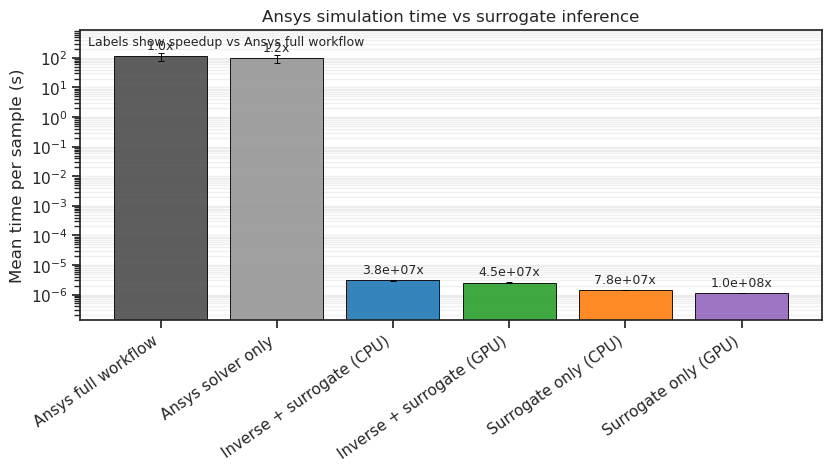

In [4]:
with sns.axes_style("ticks"), sns.plotting_context("notebook"):
    fig, ax = plt.subplots(figsize=(7.4, 4.6), layout="constrained")
    x = np.arange(len(comparison_df))
    heights = comparison_df["mean_time_per_sample_seconds"].to_numpy()
    errors = comparison_df["std_time_per_sample_seconds"].fillna(0).to_numpy()
    face_colors = [METHOD_FACE_COLORS.get(method, "#F5F5F5") for method in comparison_df["method"]]
    edge_colors = [METHOD_EDGE_COLORS.get(method, "#333333") for method in comparison_df["method"]]

    bars = ax.bar(
        x,
        heights,
        color=face_colors,
        edgecolor=edge_colors,
        linewidth=1.2,
        alpha=0.9,
    )
    ax.errorbar(
        x,
        heights,
        yerr=errors,
        fmt="none",
        ecolor=TEXT_DIM,
        elinewidth=0.9,
        capsize=2,
        capthick=0.7,
    )

    for bar, speedup in zip(bars, comparison_df["speedup_vs_ansys"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() * 1.35,
            format_speedup(speedup),
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.set_yscale("log")
    ax.set_ylabel("Mean time per sample (s)")
    ax.set_title("Ansys vs surrogate inference")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df["method"], rotation=35, ha="right")
    ax.set_ylim(
        bottom=max(heights.min() / 8, 1e-8),
        top=(heights + errors).max() * 6,
    )
    ax.grid(axis="y", which="both", alpha=0.3)
    ax.text(
        0.01,
        0.98,
        "Labels show speedup vs Ansys",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=9,
    )

save_figure(fig, "runtime_comparison_ansys_vs_surrogate_fastest")
plt.show()

## Batch Runtime Histograms

Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/runtime_comparison_batch_scaling_with_ansys.pdf
Saved plot -> /home/olivias/ML_qubit_design/experiments/model_predict_qubit_TransmonCross_Hamiltonian_params/plots/runtime_comparison_batch_scaling_with_ansys.png


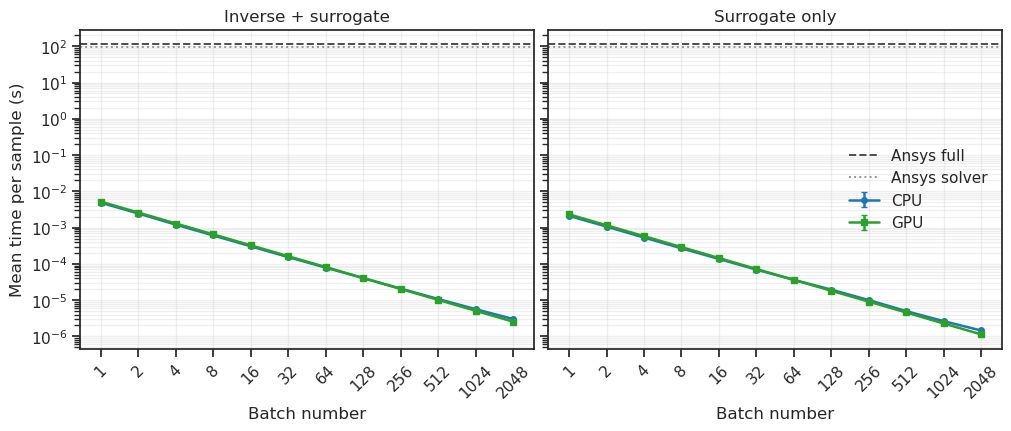

In [5]:
plot_df = ml_df.copy()
plot_df["benchmark_label"] = plot_df["benchmark"].map(BENCHMARK_LABELS).fillna(plot_df["benchmark"])

with sns.axes_style("ticks"), sns.plotting_context("notebook"):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharey=True, layout="constrained")
    for ax, benchmark in zip(axes, BENCHMARK_ORDER):
        sub = plot_df[plot_df["benchmark"] == benchmark]
        batches = sorted(sub["batch_number"].unique())
        devices = [device for device in DEVICE_ORDER if device in set(sub["device"])]
        x = np.arange(len(batches))
        width = 0.78 / max(len(devices), 1)

        for i, device in enumerate(devices):
            device_df = (
                sub[sub["device"] == device]
                .set_index("batch_number")
                .reindex(batches)
            )
            label = method_label(benchmark, device)
            offset = (i - (len(devices) - 1) / 2.0) * width
            ax.bar(
                x + offset,
                device_df["mean_time_per_sample_seconds"],
                yerr=device_df["std_time_per_sample_seconds"],
                width=width,
                color=METHOD_FACE_COLORS[label],
                edgecolor=METHOD_EDGE_COLORS[label],
                linewidth=1.1,
                alpha=0.9,
                capsize=2,
                label=device,
            )

        ax.set_yscale("log")
        ax.set_xlabel("Batch number")
        ax.set_title(BENCHMARK_LABELS.get(benchmark, benchmark))
        ax.set_xticks(x)
        ax.set_xticklabels([str(int(v)) for v in batches], rotation=45, ha="right")
        ax.grid(axis="y", which="both", alpha=0.3)

    axes[0].set_ylabel("Mean time per sample (s)")
    axes[-1].legend(frameon=False, loc="best")

save_figure(fig, "runtime_comparison_batch_histograms")
plt.show()